# Part B - Text-Based Product Matching

1) TF-IDF:-  essentially tries to give high importance to words that are important to a particular title but uncommon across the dataset.

2) Character n-grams:- Word-based methods may struggle because the tokens aren't exactly the same, character n-grams can capture pieces Ex:- "gal","ala","lax","axy"....
#Good for spelling variations,typos,concatenated words,abbrevations,partial word overlap, seller-specific formating

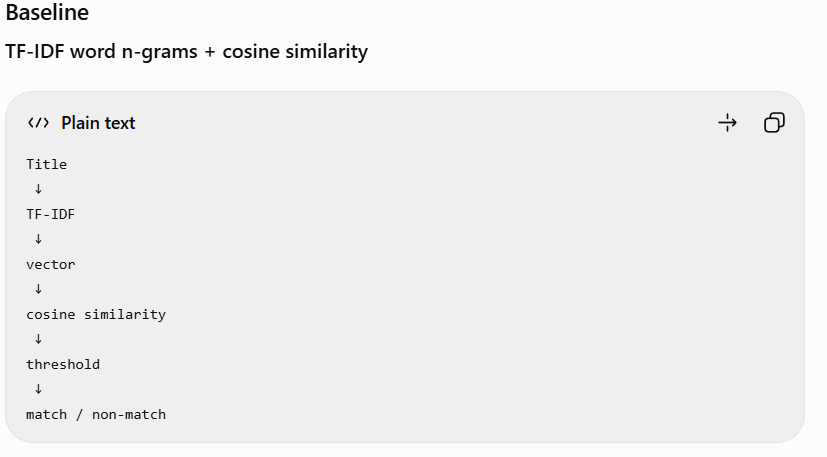

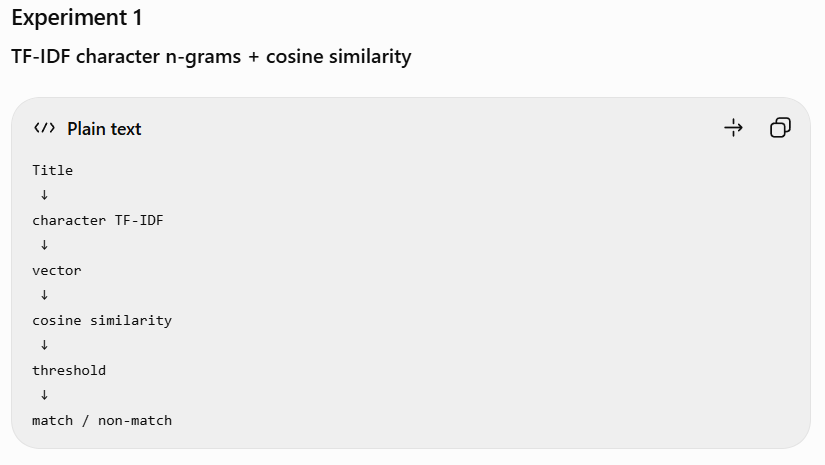

-------------------------------------------------------------------------
# TF-IDF :-


Tf-IDF gives :-
  1) Lower weights to common words
  2) Higher weights to rare words

A) TF(Term Frequency ):-
  **How often does a word appear in this particular title?**

B) IDF(Inverse Document Frequency):-
  **How uncommon is that word across all titles?**

A word is given higher score is **It appears in this title AND isn't common across the whole dataset.**

EX:-

1)Title:- Samsung Galaxy Buds Pro

2)TF-IDF:- Convert each word into weights

|Word   |score|
|-------|-----|
|Samsung|0.45 |
| Galaxy|0.52 |
| Buds  |0.61 |
| Pro   |0.30 |

3)TF-IDF Vector:- [0.45,0.52,0.61,0.30]     Z

4)If A and B are different TF-IDF vectors:- 

  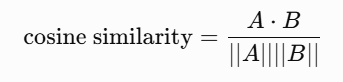

5)Then we compare it with the threshold and tell match or not match  


---------------------------------------------------------------------------
# n-gram

## n-gram:- is simply sequence of n consecutive units

### 1) Word n-gram:-

Ex:- "Samsung Galaxy Buds Pro"

A) Unigram(1-gram):- 

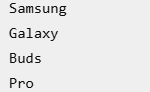

B) Bigrams (2-gram):-

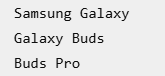

C) Trigrams (3-gram):-

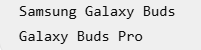


### 2) Character n-grams:-

Ex:- 

A) "buds"

Character 3-grams :- 

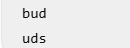

     
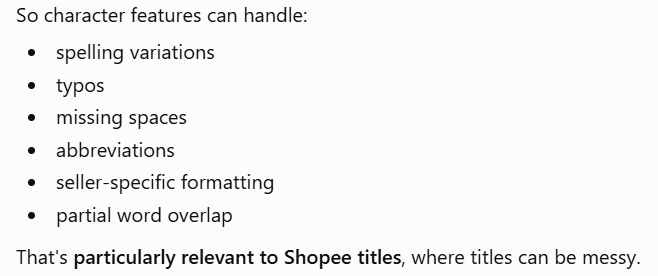



-------------------------------------------------------------------

# Product Pair COncept:--

1) If we try to form pairs of 34250 listings and work on them , we will have  to work on 586 Million pairs, which is not viable

2) Hence, we Use Product pair concept to create completely new dataset, with
columns as TITLE-A, TITLE-B, ACTUAL

3) **POSITIVE PAIRS** :-We know that there are around 11014 unique groups with listings>=2, hence we will take one pair of listings per group at random and put it in the row of new dataset and **Actual=1**, as the listings are from same group

4) **NEGATIVE PAIRS** :- We will randomly take two listings from two different
groups and put them in the rows of new dataset and **Actual=0**, but there are two way of selecting negative pairs 


    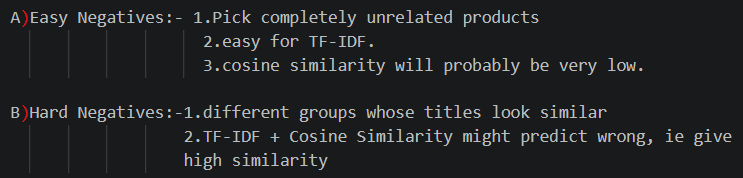          


Hence instead of worrying about this rn we will do this

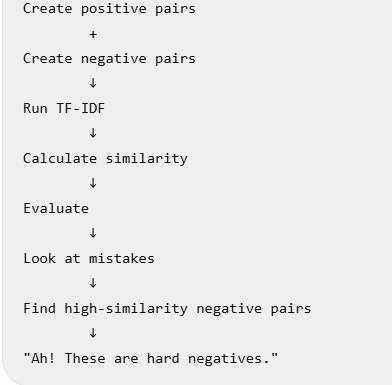

--------------------------------------------------------------------

# Similarity Score  -> Match/ Not Match

Right Now we have Pair Table as 

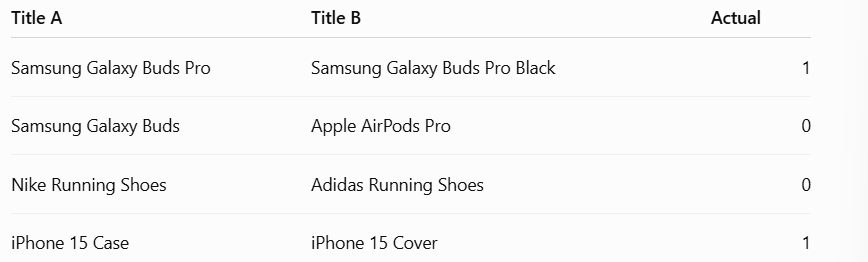

1)Now we will start feeding **Title A** and **Title B** into TF-IDF

2)We will get two Vectors A,B like 
   
   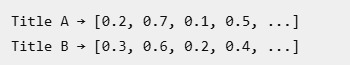

3)We will find Cosine Similarity(A,B) This will give us the Similarity score
per row

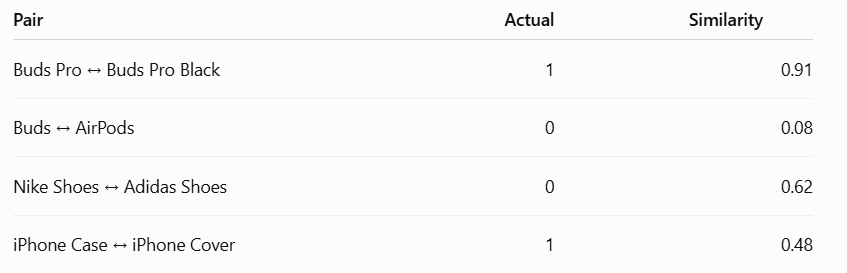

4)We will do Threshold Analysis to find optimal threshold and then find prediction based on this threshold

5)We will then Compare the prediction with actual and find Precision, Recall, F1

-------------------------------------------------------
# Threshold Analysis

1) Lower Threshold:- 

   A) More Matches Predicted.

   B) Recall Increases.

   C) Precision Decreases.

2) Higher Threshold:-

   A) Fewer Matches Predicted

   B) Recall Decreases

   C) Precision Increases

     



In [2]:
# Set the Shopee dataset path
from pathlib import Path

DATASET_DIR = Path(r"C:\Users\mahan\Downloads\shopee-product-matching")
TRAIN_PATH = DATASET_DIR / "train.csv"

print(TRAIN_PATH)

# Load the Shopee training dataset
import pandas as pd

train = pd.read_csv(TRAIN_PATH)

print(train.shape)
print(train.columns.tolist())
train.head()

C:\Users\mahan\Downloads\shopee-product-matching\train.csv
(34250, 5)
['posting_id', 'image', 'image_phash', 'title', 'label_group']


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [3]:
# Check how many listings belong to each product group
group_sizes = train.groupby("label_group").size()

print("Number of unique groups:", group_sizes.shape[0])
print("\nGroup size distribution:")
print(group_sizes.value_counts().sort_index().head(15))

Number of unique groups: 11014

Group size distribution:
2     6979
3     1779
4      862
5      468
6      282
7      154
8      118
9       91
10      48
11      38
12      39
13      28
14      19
15      19
16      13
Name: count, dtype: int64


In [4]:
# Create one positive pair from each product group
positive_pairs = []

for group_id, group in train.groupby("label_group"):
    if len(group) >= 2:
        pair = group.sample(n=2, random_state=42)
        
        positive_pairs.append({
            "title_A": pair.iloc[0]["title"],
            "title_B": pair.iloc[1]["title"],
            "actual": 1
        })

positive_pairs = pd.DataFrame(positive_pairs)

print("Positive pairs:", len(positive_pairs))
positive_pairs.head()

Positive pairs: 11014


,title_A,title_B,actual
0,Sarung celana wadimor original 100% dewasa dan...,SARUNG CELANA WADIMOR DEWASA HITAM POLOS SARCEL,1
1,RELIZA WALL STICKER PENGUKUR TINGGI BADAN JERA...,Wall Sticker / WallSticker - Submarine Measur...,1
2,Lvn Collagen / Lvn Strawberry Original BPOM RI...,LVN COLLAGEN / STROBERI,1
3,MERRY GO ROUND MAINAN BAYI GANTUNG MUSIK PUTAR...,mainan bayi gantung putar musik merry go round,1
4,TP-LINK Wireless N Router TL-WR940N 450Mbps TP...,TP-LINK Wireless N Router TL-WR940N 450Mbps TP...,1


In [5]:
# Create random negative pairs from different product groups
import numpy as np

rng = np.random.default_rng(42)

negative_pairs = []

for _ in range(len(positive_pairs)):
    idx_a, idx_b = rng.choice(len(train), size=2, replace=False)
    
    # Make sure the two listings belong to different groups
    while train.iloc[idx_a]["label_group"] == train.iloc[idx_b]["label_group"]:
        idx_b = rng.integers(len(train))
    
    negative_pairs.append({
        "title_A": train.iloc[idx_a]["title"],
        "title_B": train.iloc[idx_b]["title"],
        "actual": 0
    })

negative_pairs = pd.DataFrame(negative_pairs)

print("Negative pairs:", len(negative_pairs))
negative_pairs.head()

Negative pairs: 11014


,title_A,title_B,actual
0,Kaos anak laki laki termurah 1-9 th,Cosmos CB-281 G - Blender 2 L,0
1,Slingbag Waistbag Sashenka.Id Color Trendy I S...,B3B704 Mainan edukatif / mainan edukasi - puzz...,0
2,TUMBLR TEE LONGSLEEVE SANTUY LENGAN PANJANG PA...,All Perfect Beauty Set - Whitening Serum 30ml ...,0
3,Tempat Susu NINIO bubuk travel / Milk powder C...,5W 220V Lampu Gantung Kristal Simple Mewah San...,0
4,CEMPAL ANYAM ANTI PANAS,FOIL CURTAIN / TIRAI FOIL BALON /rumbai foil/p...,0


In [6]:
# Combine positive and negative pairs into one balanced dataset
pairs = pd.concat(
    [positive_pairs, negative_pairs],
    ignore_index=True
)

pairs = pairs.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total pairs:", len(pairs))
print("\nClass distribution:")
print(pairs["actual"].value_counts())

pairs.head()

Total pairs: 22028

Class distribution:
actual
0    11014
1    11014
Name: count, dtype: int64


,title_A,title_B,actual
0,Pengantar akuntansi 1 adaptasi indonesia edisi 4,Shinpo SIP 110 Spark Container Box CB 30 Liter...,0
1,Jepit Bulu Mata Penjepit Bulu Mata Alat,PISAU APEL WARNA RANDOM,0
2,Jilbab serut laser jumbo / jokowi laser jumbo,(1KG=7PCS) HARGA BANTING!! Daily hijab Serut j...,1
3,WBS \xe2\x9c\x85COD JAM TANGAN RUBBER S-SPORT ...,Bra Fashion Bahan Tipis dilengkapi Push-up Bra...,0
4,Ring Light selfie led bulat untuk camera hp flash,Ransel Serut Homme femme Backpack Fashion,0


In [ ]:
# Build TF-IDF vectors directly from the two title columns

vectorizer = TfidfVectorizer(   # Creating TF-IDF machine
    analyzer="word",            # Break the title into words
    ngram_range=(1, 2),         # make unigram or bigram
    min_df=2                    # Ignore a feature if it appears in only one title
)

tfidf_A = vectorizer.fit_transform(pairs["title_A"])  # All the titles in TITLE A column are converted into 47710 D vectors and stacked in a matrix
tfidf_B = vectorizer.transform(pairs["title_B"])  # We use the learning from tfidf_A and correspondingly transform All the titles in TITLE B column into 47710 D vectors and stacked in a matrix

print("Title A matrix:", tfidf_A.shape)
print("Title B matrix:", tfidf_B.shape)

Title A matrix: (22028, 47710)
Title B matrix: (22028, 47710)


In [19]:
# Calculate cosine similarity between corresponding title pairs
similarities = tfidf_A.multiply(tfidf_B).sum(axis=1).A1

pairs["similarity"] = similarities

print("Number of similarity scores:", len(similarities))
pairs[["title_A", "title_B", "actual", "similarity"]].head(50)

Number of similarity scores: 22028


,title_A,title_B,actual,similarity
0,Pengantar akuntansi 1 adaptasi indonesia edisi 4,Shinpo SIP 110 Spark Container Box CB 30 Liter...,0,0.000000
1,Jepit Bulu Mata Penjepit Bulu Mata Alat,PISAU APEL WARNA RANDOM,0,0.000000
2,Jilbab serut laser jumbo / jokowi laser jumbo,(1KG=7PCS) HARGA BANTING!! Daily hijab Serut j...,1,0.135950
3,WBS \xe2\x9c\x85COD JAM TANGAN RUBBER S-SPORT ...,Bra Fashion Bahan Tipis dilengkapi Push-up Bra...,0,0.017652
4,Ring Light selfie led bulat untuk camera hp flash,Ransel Serut Homme femme Backpack Fashion,0,0.000000
5,Dnm Pensil Bronzer / Highlighter / Contour 3D,Dnm Pensil Highlighter / Bronzer / Contour 3D,1,0.900021
6,Baseus Kabel Lightning Cable Iphone Auto Disco...,BASEUS KABEL DATA TYPE-C AUTOMATIC POWER-OFF F...,1,0.175338
7,Kumpulan Hadis Arbain Nawawi,Konektor Masker Hijab/Pengait Tali Masker,0,0.000000
8,SQUARE GRILL PAN 20CM,Nestle Cerelac Bubur Bayi Instant Usia 6-24 Bu...,0,0.000000
9,Bola Lampu LED - PREMIER 3 watt Hannochs,Lampu LED PREMIER 3 Watt/ 5 Watt/ 7 Watt/ 9 Wa...,1,0.558479


In [20]:
# Compare similarity distributions for matches and non-matches
positive_scores = pairs.loc[pairs["actual"] == 1, "similarity"]
negative_scores = pairs.loc[pairs["actual"] == 0, "similarity"]

print("Actual = 1")
print(positive_scores.describe())

print("\nActual = 0")
print(negative_scores.describe())

Actual = 1
count    11014.000000
mean         0.547074
std          0.275098
min          0.000000
25%          0.334902
50%          0.545929
75%          0.767880
max          1.000000
Name: similarity, dtype: float64

Actual = 0
count    11014.000000
mean         0.002002
std          0.013412
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.612209
Name: similarity, dtype: float64


### Threshold Analysis

In [21]:
# Evaluate precision, recall, and F1 across different thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds:
    predictions = (pairs["similarity"] >= threshold).astype(int)
    
    results.append({
        "threshold": threshold,
        "precision": precision_score(pairs["actual"], predictions),
        "recall": recall_score(pairs["actual"], predictions),
        "f1": f1_score(pairs["actual"], predictions)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.1,0.996744,0.944888,0.970124
1,0.2,0.999174,0.878881,0.935175
2,0.3,0.999769,0.786817,0.880602
3,0.4,0.999865,0.674868,0.805833
4,0.5,0.999836,0.555021,0.713802
5,0.6,0.999791,0.435355,0.606578
6,0.7,1.000000,0.319593,0.484381
7,0.8,1.000000,0.217178,0.356855
8,0.9,1.000000,0.130833,0.231393


In [22]:
# Inspect the classification results at the best tested threshold
from sklearn.metrics import confusion_matrix

threshold = 0.1
predictions = (pairs["similarity"] >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    pairs["actual"],
    predictions
).ravel()

print("Threshold:", threshold)
print("True Positives :", tp)
print("False Positives:", fp)
print("True Negatives :", tn)
print("False Negatives:", fn)

Threshold: 0.1
True Positives : 10407
False Positives: 34
True Negatives : 10980
False Negatives: 607


threshold=0.1 means that, Even a relatively small amount of textual similarity is enough for me to call these products a match, thats the reason the recall is high

In [23]:
# Inspect genuine matches that the TF-IDF baseline missed
false_negatives = pairs[
    (pairs["actual"] == 1) &
    (pairs["similarity"] < 0.1)
].sort_values("similarity")

false_negatives[
    ["title_A", "title_B", "similarity"]
].head(20)

,title_A,title_B,similarity
21469,Zara Splend ^,Kezia Sweater,0.0
1407,ERIC KOKO Kemeja koko pria Lengan Panjang Baha...,MEN CLOTH KOMBINASI SILVER SERIES,0.0
12043,BUBBLE WRAP / SAFETY PACKING,BUBBLEWRAP khusus pembelian barang,0.0
12028,[Kode 018-032] CARTOON - Griptok Ring 3D/ Phon...,Jepit Rambut Model Bobby Pin Motif Bunga Gaya ...,0.0
21324,LAL-Role Play Finger Puppets Cloth Plush Doll ...,"[LOGU] Mainan bayi boneka jari animal,boneka m...",0.0
21251,SAMYUN WAN,Sanyumwan Wisdom Original - Penggemuk Badan,0.0
21204,LEST PANT/CELANA PANT WANITA,KING_FASHION LEST PANTS BABYTERRY FIT TO L,0.0
21179,Silvia maxy kids ( anak tanggung),Zahwa dres remaja ORI SHOFIYA,0.0
21176,(READY-JKT) LAMEILA EYESHADOW 10 COLORS PLAY C...,(20 \xc3\x97 30cm) Hiasan Dinding Walldecor Te...,0.0
11961,Pempek palembang,"Mpek""",0.0


## Experiment 1 Conclusion — Word-Level TF-IDF

The first baseline represents each product title using **word-level TF-IDF with unigram and bigram features**, followed by cosine similarity between title pairs.

### Results

At a similarity threshold of **0.1**:

- Precision: **99.67%**
- Recall: **94.49%**
- F1-score: **97.01%**
- True Positives: **10,407**
- False Positives: **34**
- True Negatives: **10,980**
- False Negatives: **607**

### Observations

- Matching products generally received substantially higher similarity scores than non-matching products.
- Many unrelated title pairs had a similarity of **0**, while genuine matches could reach similarities close to **1.0**.
- Increasing the similarity threshold made the model more strict:
  - Precision remained very high.
  - Recall decreased because more genuine matches were rejected.
- A threshold of **0.1** gave the best F1-score among the tested thresholds.

### Strengths

- Simple and computationally efficient.
- Easy to interpret because similarity is based on shared words and phrases.
- Word n-grams capture both individual product terms and short phrases.

### Limitations

The false-negative examples show that word-level TF-IDF struggles when two listings describe the same product using:

- Different words or seller terminology
- Abbreviations
- Spelling variations
- Different word forms
- Missing or concatenated words
- Very short or noisy titles

For example, titles such as `SAMYUN WAN` and `Sanyumwan Wisdom Original - Penggemuk Badan` can refer to the same product while having very little exact word overlap.

### Conclusion

Word-level TF-IDF provides a strong and interpretable baseline for product matching. However, its reliance on exact word overlap limits its ability to handle spelling variations, abbreviations, and noisy seller-generated titles.

Therefore, the next experiment will investigate **character-level TF-IDF**, which may capture partial word matches and character-level similarities that word-level features miss.

![Experiment 1_ Word-Level TF-IDF Results.png](<attachment:experiment1_results.png>)
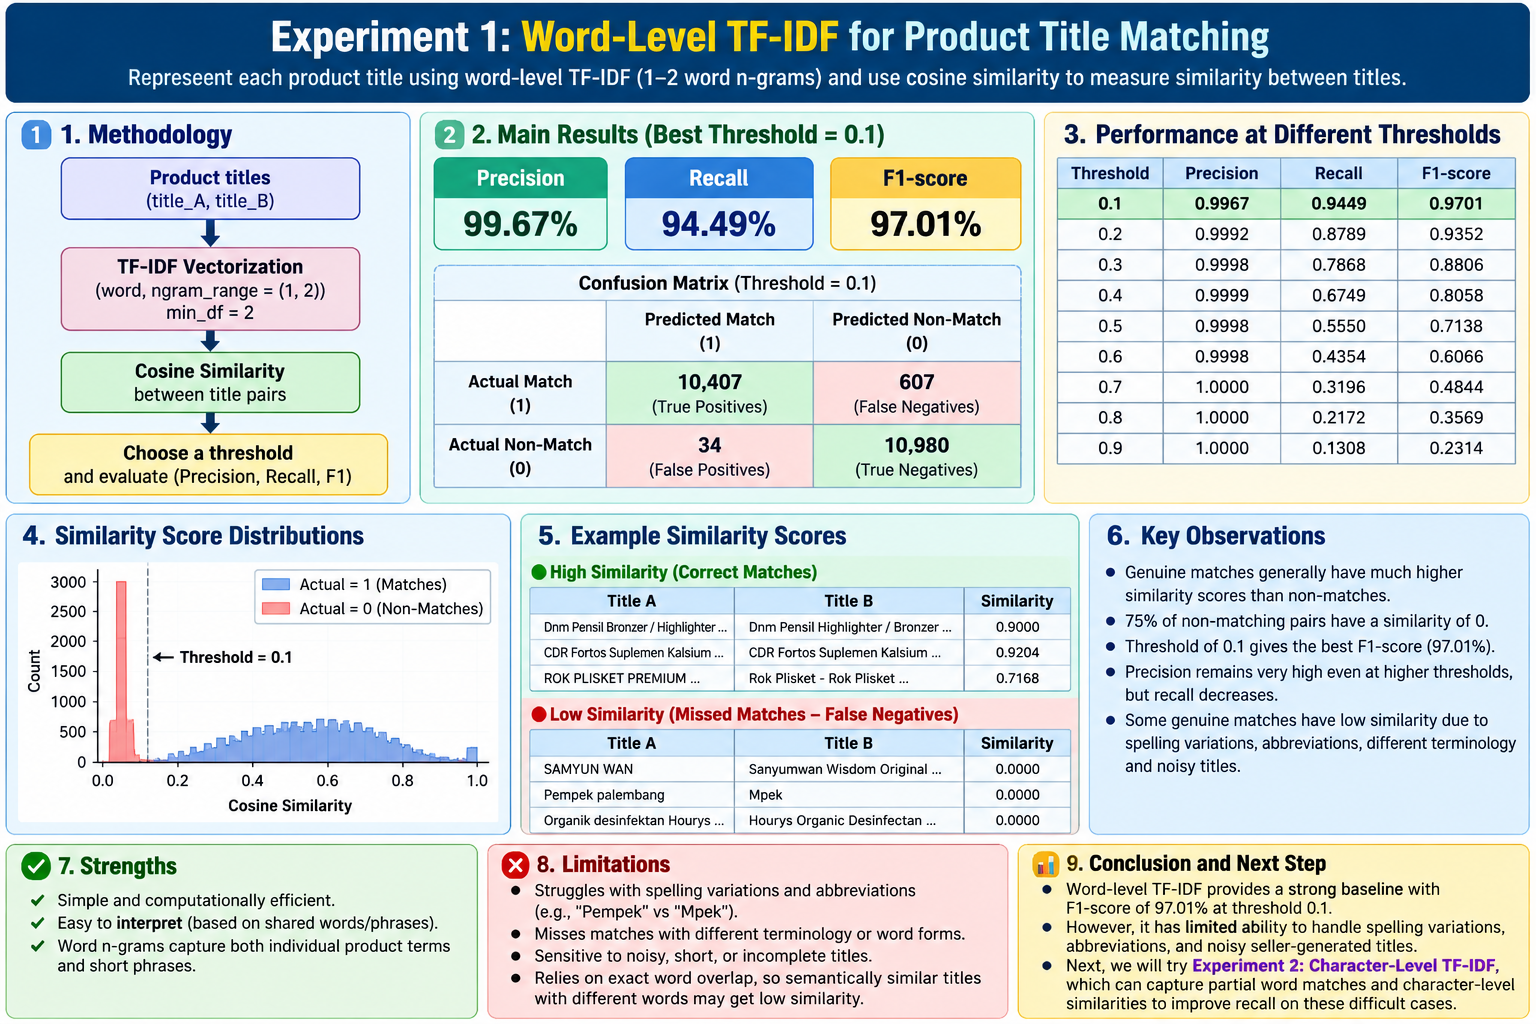

# Experiment 2:- Character-level TF-IDF.

In [24]:
# Create a character-level TF-IDF representation for all title pairs
from sklearn.feature_extraction.text import TfidfVectorizer

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5), #Length of characters can be 3-5
    min_df=2
)

char_tfidf_A = char_vectorizer.fit_transform(pairs["title_A"])
char_tfidf_B = char_vectorizer.transform(pairs["title_B"])

print("Title A matrix:", char_tfidf_A.shape)
print("Title B matrix:", char_tfidf_B.shape)

Title A matrix: (22028, 176447)
Title B matrix: (22028, 176447)


In [25]:
# Calculate cosine similarity between corresponding character-level title pairs
char_similarities = char_tfidf_A.multiply(char_tfidf_B).sum(axis=1).A1

pairs["char_similarity"] = char_similarities

print("Number of similarity scores:", len(char_similarities))

pairs[
    ["title_A", "title_B", "actual", "char_similarity"]
].head(50)

Number of similarity scores: 22028


,title_A,title_B,actual,char_similarity
0,Pengantar akuntansi 1 adaptasi indonesia edisi 4,Shinpo SIP 110 Spark Container Box CB 30 Liter...,0,0.006054
1,Jepit Bulu Mata Penjepit Bulu Mata Alat,PISAU APEL WARNA RANDOM,0,0.000000
2,Jilbab serut laser jumbo / jokowi laser jumbo,(1KG=7PCS) HARGA BANTING!! Daily hijab Serut j...,1,0.226107
3,WBS \xe2\x9c\x85COD JAM TANGAN RUBBER S-SPORT ...,Bra Fashion Bahan Tipis dilengkapi Push-up Bra...,0,0.040175
4,Ring Light selfie led bulat untuk camera hp flash,Ransel Serut Homme femme Backpack Fashion,0,0.008922
5,Dnm Pensil Bronzer / Highlighter / Contour 3D,Dnm Pensil Highlighter / Bronzer / Contour 3D,1,0.888020
6,Baseus Kabel Lightning Cable Iphone Auto Disco...,BASEUS KABEL DATA TYPE-C AUTOMATIC POWER-OFF F...,1,0.189731
7,Kumpulan Hadis Arbain Nawawi,Konektor Masker Hijab/Pengait Tali Masker,0,0.000000
8,SQUARE GRILL PAN 20CM,Nestle Cerelac Bubur Bayi Instant Usia 6-24 Bu...,0,0.001111
9,Bola Lampu LED - PREMIER 3 watt Hannochs,Lampu LED PREMIER 3 Watt/ 5 Watt/ 7 Watt/ 9 Wa...,1,0.544411


In [26]:
# Compare character-level similarity distributions for matches and non-matches
char_positive_scores = pairs.loc[
    pairs["actual"] == 1, "char_similarity"
]

char_negative_scores = pairs.loc[
    pairs["actual"] == 0, "char_similarity"
]

print("Actual = 1")
print(char_positive_scores.describe())

print("\nActual = 0")
print(char_negative_scores.describe())

Actual = 1
count    11014.000000
mean         0.524071
std          0.252672
min          0.000000
25%          0.337727
50%          0.507927
75%          0.706921
max          1.000000
Name: char_similarity, dtype: float64

Actual = 0
count    11014.000000
mean         0.006667
std          0.015663
min          0.000000
25%          0.000000
50%          0.002457
75%          0.006701
max          0.610585
Name: char_similarity, dtype: float64


## Threshold Analysis

In [27]:
# Evaluate precision, recall, and F1 across character-level similarity thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

char_threshold_results = []

for threshold in thresholds:
    predictions = (pairs["char_similarity"] >= threshold).astype(int)
    
    char_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(pairs["actual"], predictions),
        "recall": recall_score(pairs["actual"], predictions),
        "f1": f1_score(pairs["actual"], predictions)
    })

char_threshold_results = pd.DataFrame(char_threshold_results)

char_threshold_results

,threshold,precision,recall,f1
0,0.1,0.996521,0.962230,0.979075
1,0.2,0.999191,0.897403,0.945566
2,0.3,0.999772,0.796169,0.886429
3,0.4,0.999862,0.658344,0.793934
4,0.5,0.999822,0.510986,0.676320
5,0.6,0.999756,0.371346,0.541543
6,0.7,1.000000,0.255765,0.407346
7,0.8,1.000000,0.169602,0.290017
8,0.9,1.000000,0.097875,0.178300


In [28]:
# Find the best character TF-IDF threshold using a finer threshold grid
fine_thresholds = np.arange(0.05, 0.151, 0.01)

fine_results = []

for threshold in fine_thresholds:
    predictions = (pairs["char_similarity"] >= threshold).astype(int)

    fine_results.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(pairs["actual"], predictions),
        "recall": recall_score(pairs["actual"], predictions),
        "f1": f1_score(pairs["actual"], predictions)
    })

fine_threshold_results = pd.DataFrame(fine_results)

fine_threshold_results

,threshold,precision,recall,f1
0,0.05,0.979662,0.979662,0.979662
1,0.06,0.985974,0.976484,0.981206
2,0.07,0.990209,0.973307,0.981685
3,0.08,0.992936,0.969947,0.981307
4,0.09,0.995420,0.966951,0.980979
5,0.10,0.996521,0.962230,0.979075
6,0.11,0.997352,0.957418,0.976977
7,0.12,0.997717,0.952152,0.974402
8,0.13,0.997893,0.945796,0.971146
9,0.14,0.998265,0.940076,0.968297


Hence threshold 0.07 is better than 0.1

In [29]:
# Inspect classification results at the best character TF-IDF threshold
threshold = 0.07

predictions = (pairs["char_similarity"] >= threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    pairs["actual"],
    predictions
).ravel()

print("Threshold:", threshold)
print("True Positives :", tp)
print("False Positives:", fp)
print("True Negatives :", tn)
print("False Negatives:", fn)

Threshold: 0.07
True Positives : 10720
False Positives: 106
True Negatives : 10908
False Negatives: 294


In [30]:
# Inspect genuine matches missed by character-level TF-IDF
char_false_negatives = pairs[
    (pairs["actual"] == 1) &
    (pairs["char_similarity"] < 0.07)
].sort_values("char_similarity")

char_false_negatives[
    ["title_A", "title_B", "char_similarity"]
].head(20)

,title_A,title_B,char_similarity
1245,MLP Black Original,Tas Selempang Waistbag Keren Murah COD,0.0
1643,KANNA MAXI DRESS COMBI // LIVIA COMBI MAXI,Ring belt / korean belt / sabuk wanita / belt ...,0.0
1718,Sabun Kecantikan Klinskin Beauty Soap,JAM GSHOCK BONUS FITHO,0.0
19276,Cincin Vintage Motif Hati Warna Gold / Silver ...,10 PCS SOLID RING OVAL,0.0
17883,RAISA DRESS (Busui),GAMIS POLOS JUMBO/ GAMIS BALOTELI/GAMIS SERENA...,0.0
17888,CEYSTAL DRESS,DASTER ARAB ZEERA ELORA BY ZEERA ORI,0.0
19889,GENARO MAROON,Sweater pria Kombinasi because termurah,0.0
17843,Hak Tahu T5 BERLIAN,GRATIS ONGKIR !! Sappun heels Mika batam wanit...,0.0
18082,NTS17 TEPLEK CANTIK,FLAT SHOES GELANG KERUT,0.0
17177,Termurah Eric summers neo gracella gamis grace...,MIKOLE SHANGHAI DRESS BRUKAT DRESS JEREMIA SF ...,0.0


In [31]:
# Inspect different products incorrectly matched by character TF-IDF
char_false_positives = pairs[
    (pairs["actual"] == 0) &
    (pairs["char_similarity"] >= 0.07)
].sort_values("char_similarity", ascending=False)

char_false_positives[
    ["title_A", "title_B", "char_similarity"]
].head(20)

,title_A,title_B,char_similarity
1216,Bubble wrap untuk packing,Bubble Wrap,0.610585
13043,11Pcs / Set Resistance Band Karet Latex Elasti...,11 IN 1 PRO RESISTANCE BAND SET FITNESS GYM ST...,0.321488
639,Cussons Lotion 100gr Cream Anti Nyamuk Moscare...,Cussons Baby Gift Mini Bag / Cussons Gift Bag Set,0.286437
6998,Madame gie total cover BB cushion sale 50%,DEWYCEL SUPER COVER CUSHION,0.247593
13865,TW02-15 ORIGINAL HAOSHUAI Tas Selempang waistb...,Tas Selempang Wanita Fashion,0.243900
17069,Madame Gie Eyeshadow Sensous Drama Queen - MakeUp,Madame Gie N-Moji Earth Series (Satuan) - MakeUp,0.242676
1127,1 Pasang Sarung Tangan Lebah untuk Ternak Leba...,SARUNG TANGAN Nike,0.236652
15770,HOTSHOP WAISTBAG AS HAUL,Waistbag Pria Simple Buffback Termurah,0.216009
13079,MARKS AND SPENCER HAND & BODY LOTION 250 ml 25...,Scarlett Whitening Body Lotion,0.186708
4679,THERASKIN PAKET ACNE WHITENING GLOWING FALIA P...,THERASKIN ORIGINAL PAKET FLEK BPOM (UNTUK WAJA...,0.174628


## Experiment 2 Conclusion — Character-Level TF-IDF

Character-level TF-IDF was evaluated using character n-grams of length 3–5 and cosine similarity.

### Results

The best threshold from the fine-grained threshold search was **0.07**.

- Precision: **99.02%**
- Recall: **97.33%**
- F1-score: **98.17%**
- True Positives: **10,720**
- False Positives: **106**
- True Negatives: **10,908**
- False Negatives: **294**

### Comparison with Word-Level TF-IDF

| Metric | Word TF-IDF | Character TF-IDF |
|---|---:|---:|
| Best threshold | 0.10 | **0.07** |
| Precision | 99.67% | 99.02% |
| Recall | 94.49% | **97.33%** |
| F1-score | 97.01% | **98.17%** |
| False negatives | 607 | **294** |

### Observations

Character-level TF-IDF improved recall substantially compared with word-level TF-IDF. The number of false negatives decreased from 607 to 294.

This improvement comes from character n-grams being less dependent on exact word boundaries. They can capture partial overlaps caused by spelling variations, abbreviations, formatting differences, and concatenated words.

However, character-level similarity also produced more false positives. Different products can share common character patterns because of the same brand, product category, model number, or frequently occurring terms.

### Error Analysis

#### False negatives

Some genuine matches still received very low similarity because the two sellers used completely different vocabulary to describe the same product.

Examples include:

- `RAISA DRESS (Busui)` vs `GAMIS POLOS JUMBO...`
- `BERGO TALI NABILA` vs `Khimar Khadijah`
- `Dm20 sneakers` vs `Sepatu selp dn 20`

These cases require semantic understanding rather than just lexical or character overlap.

#### False positives

Some different products received relatively high character similarity because they shared strong textual patterns.

For example:

- `Bubble wrap untuk packing` vs `Bubble Wrap`
- `Madame Gie Eyeshadow...` vs `Madame Gie N-Moji...`
- `JBL T110BT...` vs `Speaker Bluetooth JBL...`

This shows that character similarity alone can confuse products that share brands, categories, or common terms.

### Conclusion

Character-level TF-IDF performs slightly better than word-level TF-IDF on this balanced pair dataset, mainly because of its higher recall.

However, both approaches fundamentally rely on **surface-level textual similarity**. They struggle when two listings use very different words for the same product and can also confuse different products with similar wording.

The next stage can therefore investigate whether a more semantic representation can address these limitations.

-----------------------------------------------------------------

# HARD NEGATIVE PAIRS

Before we used Easy Negative Pairs whose similarities was near zero and easy to distinguish, now lets take the cases of hard negative pairs in which the titles in pair have high similarity but belong to different group(ie Actual=0)

In [32]:
# Inspect the hardest negative pairs for character-level TF-IDF
hard_negatives = pairs[
    (pairs["actual"] == 0)
].sort_values("char_similarity", ascending=False)

hard_negatives[
    ["title_A", "title_B", "char_similarity"]
].head(30)

,title_A,title_B,char_similarity
1216,Bubble wrap untuk packing,Bubble Wrap,0.610585
13043,11Pcs / Set Resistance Band Karet Latex Elasti...,11 IN 1 PRO RESISTANCE BAND SET FITNESS GYM ST...,0.321488
639,Cussons Lotion 100gr Cream Anti Nyamuk Moscare...,Cussons Baby Gift Mini Bag / Cussons Gift Bag Set,0.286437
6998,Madame gie total cover BB cushion sale 50%,DEWYCEL SUPER COVER CUSHION,0.247593
13865,TW02-15 ORIGINAL HAOSHUAI Tas Selempang waistb...,Tas Selempang Wanita Fashion,0.243900
17069,Madame Gie Eyeshadow Sensous Drama Queen - MakeUp,Madame Gie N-Moji Earth Series (Satuan) - MakeUp,0.242676
1127,1 Pasang Sarung Tangan Lebah untuk Ternak Leba...,SARUNG TANGAN Nike,0.236652
15770,HOTSHOP WAISTBAG AS HAUL,Waistbag Pria Simple Buffback Termurah,0.216009
13079,MARKS AND SPENCER HAND & BODY LOTION 250 ml 25...,Scarlett Whitening Body Lotion,0.186708
4679,THERASKIN PAKET ACNE WHITENING GLOWING FALIA P...,THERASKIN ORIGINAL PAKET FLEK BPOM (UNTUK WAJA...,0.174628


## Hard Negative Analysis

Randomly sampled negative pairs are often easy to distinguish because unrelated products have little textual overlap. Therefore, we examined negative pairs with the highest character-level TF-IDF similarity.

These pairs represent difficult cases where different products have similar titles.

### Examples

| Product A | Product B | Character Similarity |
|---|---|---:|
| Bubble wrap untuk packing | Bubble Wrap | 0.6106 |
| 11Pcs Resistance Band... | 11 IN 1 Resistance Band... | 0.3215 |
| Cussons Lotion... | Cussons Baby Gift... | 0.2864 |
| Madame Gie BB Cushion... | DEWYCEL Super Cover Cushion | 0.2476 |
| Madame Gie Eyeshadow... | Madame Gie N-Moji... | 0.2427 |

### Observations

The difficult negative pairs commonly share:

- The same brand but different products
- The same product category
- Common product-related words
- Similar model numbers or character sequences
- Seller terminology that is common across listings

This demonstrates that character-level similarity can incorrectly match different products when they share strong lexical patterns.

### Limitation of Random Negative Sampling

The negative pairs in this experiment were initially generated randomly from different product groups. Consequently, many negative pairs are relatively easy.

The hard-negative analysis partially addresses this issue by examining high-similarity negative pairs, but the resulting F1-score should not be interpreted as a complete measure of real-world product-matching performance.

A stronger evaluation could deliberately construct a hard-negative dataset containing different products with high textual similarity.

----------------------------------------------------------------------------

# Experiment 3:- pretrained sentence-embedding model

use a pretrained sentence-embedding model to convert each title into a meaning-based vector, then use the same cosine-similarity + threshold pipeline.

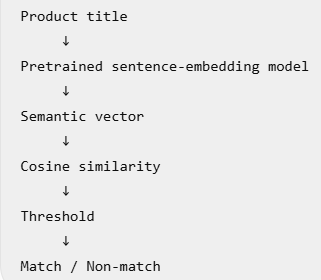

we will have to install :- pip install sentence-transformers